In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# -----------------------------
# GLOBAL PARAMETERS
# -----------------------------
time_steps = 100
escape_threshold = 1000
num_simulations = 1000
random_seed = 42
np.random.seed(random_seed)

In [ ]:
# SINGLE SIMULATION FUNCTION
def run_simulation(p_detect_initial, decay_rate, growth_rate):
    tumor_size = 1

    for t in range(time_steps):

        # Stochastic tumor growth using a Poisson birth process
        growth = np.random.poisson(growth_rate * tumor_size)
        tumor_size += growth

        # Immune detection probability declines over time to represent aging
        p_detect = p_detect_initial * np.exp(-decay_rate * t)

        # Tumor eliminated if immune detection occurs
        if np.random.rand() < p_detect:
            return 0

        # Tumor escapes if it reaches the escape threshold
        if tumor_size >= escape_threshold:
            return 1

    return 0

In [4]:
# ESTIMATE ESCAPE PROBABILITY
def estimate_escape_probability(p_detect_initial, decay_rate, growth_rate):
    outcomes = []

    for _ in range(num_simulations):
        result = run_simulation(p_detect_initial, decay_rate, growth_rate)
        outcomes.append(result)

    return np.mean(outcomes)

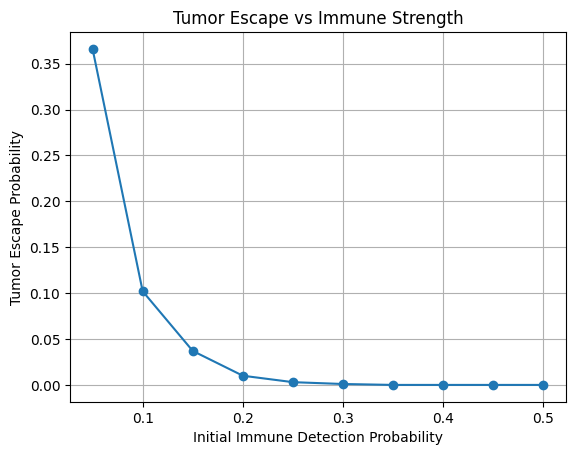

In [ ]:
# GRAPH 1: ESCAPE VS IMMUNE STRENGTH
p_values = np.linspace(0.05, 0.5, 10)
escape_probs_immune = []

fixed_decay_rate = 0.02
fixed_growth_rate = 0.3

for p in p_values:
    prob = estimate_escape_probability(p, fixed_decay_rate, fixed_growth_rate)
    escape_probs_immune.append(prob)

plt.figure()
plt.plot(p_values, escape_probs_immune, marker='o')
plt.xlabel("Initial Immune Detection Probability")
plt.ylabel("Tumor Escape Probability")
plt.title("Tumor Escape vs Immune Strength")
plt.grid()
plt.show()

Graph 1: This simulation looks at how immune strength affects tumor escape probability. The immune detection probability p represents how likely the immune system is to recognize and eliminate tumor cells during each time step. Stronger immune detection should reduce tumor escape because the tumor is more likely to be eliminated before reaching the escape threshold.

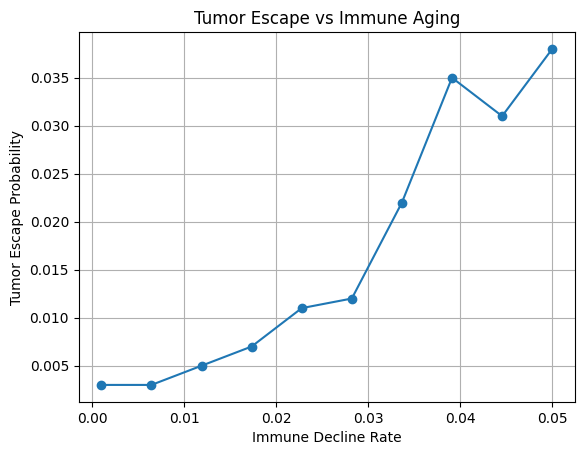

In [ ]:
# GRAPH 2: ESCAPE VS IMMUNE AGING
decay_values = np.linspace(0.001, 0.05, 10)
escape_probs_aging = []

fixed_p_detect = 0.2

for decay in decay_values:
    prob = estimate_escape_probability(fixed_p_detect, decay, fixed_growth_rate)
    escape_probs_aging.append(prob)

plt.figure()
plt.plot(decay_values, escape_probs_aging, marker='o')
plt.xlabel("Immune Decline Rate")
plt.ylabel("Tumor Escape Probability")
plt.title("Tumor Escape vs Immune Aging")
plt.grid()
plt.show()

Graph 2: This simulation looks at how immune aging influences tumor escape probability over time. Immune detection probability gradually decreases throughout the simulation to represent age-related immune decline, including reduced adaptive immune efficiency and lower T-cell activity. As immune surveillance weakens, tumor escape becomes more likely.

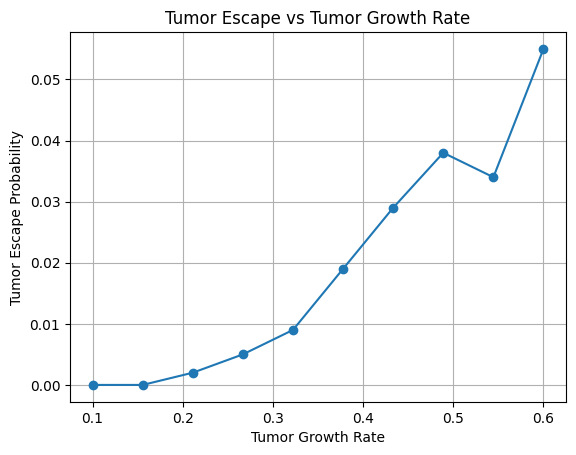

In [ ]:
# GRAPH 3: ESCAPE VS TUMOR GROWTH RATE
growth_values = np.linspace(0.1, 0.6, 10)
escape_probs_growth = []

for growth_rate in growth_values:
    prob = estimate_escape_probability(fixed_p_detect, fixed_decay_rate, growth_rate)
    escape_probs_growth.append(prob)

plt.figure()
plt.plot(growth_values, escape_probs_growth, marker='o')
plt.xlabel("Tumor Growth Rate")
plt.ylabel("Tumor Escape Probability")
plt.title("Tumor Escape vs Tumor Growth Rate")
plt.grid()
plt.show()

Graph 3: This simulation is showing how tumor growth rate affects the likelihood of immune escape. Faster tumor growth allows the tumor population to reach the escape threshold more quickly, reducing the amount of time available for immune recognition. This simulation helps show how tumor proliferation competes with immune surveillance dynamics.

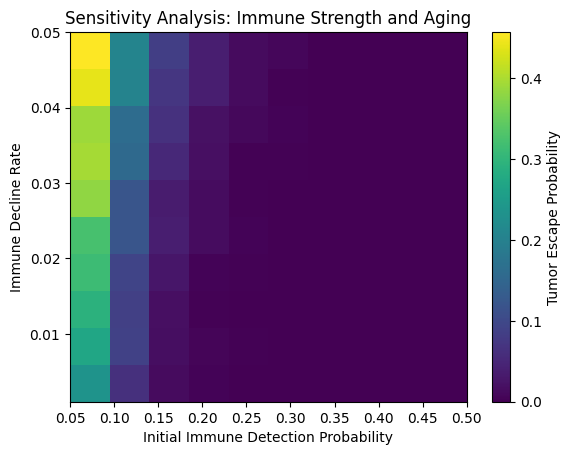

In [ ]:
# GRAPH 4: SENSITIVITY ANALYSIS
# IMMUNE STRENGTH + AGING COMBINED
p_values_heatmap = np.linspace(0.05, 0.5, 10)
decay_values_heatmap = np.linspace(0.001, 0.05, 10)

heatmap_results = np.zeros((len(decay_values_heatmap), len(p_values_heatmap)))

for i, decay in enumerate(decay_values_heatmap):
    for j, p in enumerate(p_values_heatmap):
        heatmap_results[i, j] = estimate_escape_probability(
            p,
            decay,
            fixed_growth_rate
        )

plt.figure()
plt.imshow(
    heatmap_results,
    origin="lower",
    aspect="auto",
    extent=[
        p_values_heatmap[0],
        p_values_heatmap[-1],
        decay_values_heatmap[0],
        decay_values_heatmap[-1]
    ]
)
plt.colorbar(label="Tumor Escape Probability")
plt.xlabel("Initial Immune Detection Probability")
plt.ylabel("Immune Decline Rate")
plt.title("Sensitivity Analysis: Immune Strength and Aging")
plt.show()

Graph 4: Finally, this sensitivity analysis/heatmap examines the combined effects of immune strength and immune aging on tumor escape probability. Multiple combinations of immune detection probability and immune decline rate were simulated to observe how these variables interact. The heatmap provides a broader view of how changes in immune function influence tumor progression outcomes.

In [ ]:
# PRINT EXAMPLE RESULT
example_prob = estimate_escape_probability(
    p_detect_initial=0.2,
    decay_rate=0.02,
    growth_rate=0.3
)

print("Example tumor escape probability:", example_prob)

Example tumor escape probability: 0.009
